In [1]:
from dyMES.model import model
import matplotlib.pyplot as plt

## Running DyMES

A dyMES model can be initialized by creating an instance of the `model` class, this will store all states, lambdas, derivatives, and parameters.

In order to run the model out, the function `model.update` should be called. A simple example, using the transition function defined in `default_models.py` can be seen below. The argument `error_lim` can be used to ensure that all constraints are being met, if an error larger than `error_lim` occurs, an assertion error will be raised.

Using Default Transition Function
Steady State at N = 100
Parameters: {'m_0': 100, 'S': 100, 'K': 400, 'd_0': 0.1, 'c0': 0.00137, 'c1': 1, 'c2': 0, 'tau': 0.05, '<n>_(t-1)': 0, 'm_(t-1)': 100}


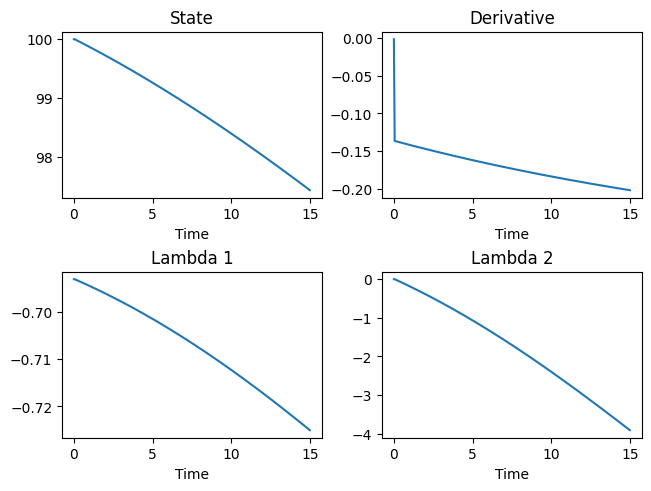

In [2]:
pandemic_dymes = model(100) #Starting off with 100 infected individuals
pandemic_dymes.update(300 * 0.05,0.05, error_lim=0.1) #Running it for 300 iterations with a timestep of 0.05
pandemic_dymes.graph() #Graphing the final result

## Finding Initial Steady State
It's sometimes helpful to calculate the value for a given parameter such that the model starts off at an initial steady state. This can be done with `model.find_steady_state_params`

Using Default Transition Function
Steady State at N = 100
Parameters: {'m_0': 100, 'S': 100, 'K': 400, 'd_0': 0.1, 'c0': 0.00137, 'c1': 1, 'c2': 0, 'tau': 0.05, '<n>_(t-1)': 0.9744149890779814, 'm_(t-1)': 98.51779479677532, 'I_(t-1)': 97.44020769419453}


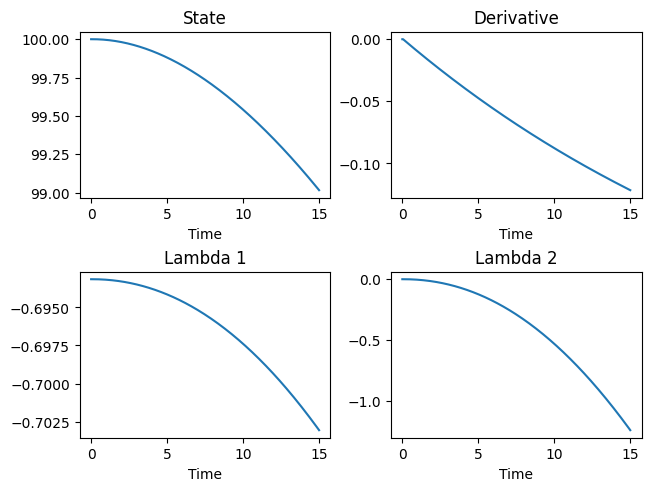

In [3]:
pandemic_dymes = model(100)
c0_steady_state_val = pandemic_dymes.find_steady_state_params('c0')
pandemic_dymes.update_param('c0', c0_steady_state_val)
pandemic_dymes.update(300 * 0.05,0.05) # Note: tau in this should match up with tau in the dictionary of parameters
pandemic_dymes.graph()

## Changing parameters

All parameters such as `r0` and `d0` are stored in `model.params`, however the correct way to perturb any of these parameters is to call `model.update_param()`.

This is because parameters must be changed in a way such that all constraints can still be satisfied.

Using Default Transition Function
Steady State at N = 100
Parameters: {'m_0': 100, 'S': 100, 'K': 400, 'd_0': 0.1, 'c0': 0.0013889612306196503, 'c1': 1, 'c2': 0, 'tau': 0.05, '<n>_(t-1)': 0.9902307746415243, 'm_(t-1)': 98.50502080358365, 'I_(t-1)': 99.02231383227819}


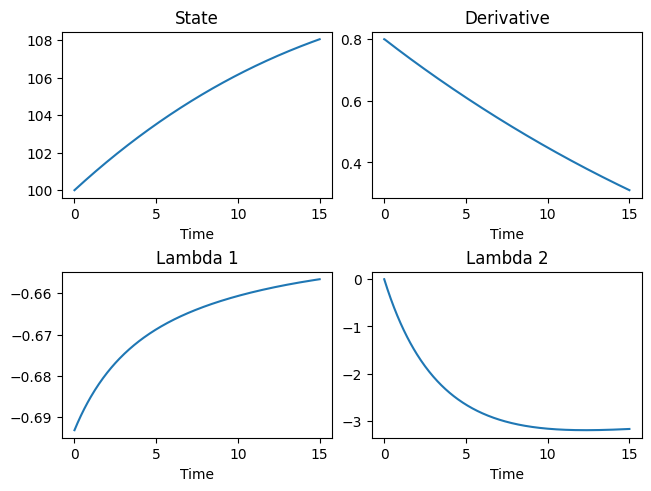

In [4]:
pandemic_dymes = model(100) #Starting off with 110 Individuals
pandemic_dymes.update_param('c0', 0.0015) # Increase infection rate c0
pandemic_dymes.update(300 * 0.05,0.05)
pandemic_dymes.graph() #Graphing the final result

## Accessing Values

To access any of the variables, you can call `model.states`, `model.lambdas`, or `model.derivatives`, this will give you a list of all the stored values.

In [5]:
print("final state: " + str(pandemic_dymes.states[-1]))
print("final derivative: " + str(pandemic_dymes.derivatives[-1]))
print("final lambdas: " + str(pandemic_dymes.lambdas[-1]))

final state: 108.04734044240608
final derivative: 0.31019791619590076
final lambdas: [-0.65661958 -3.17021289]
